In [2]:
from pyspark import SparkContext
sc = SparkContext()

In [ ]:
xyz = sc.parallelize([1,2,2,3,3,4])

In [ ]:
type(xyz)

pyspark.core.rdd.RDD

In [ ]:
xyz.collect()

[1, 2, 2, 3, 3, 4]

In [ ]:
xyz.take(2)

[1, 2]

In [ ]:
xyz.first()

1

In [ ]:
xyz.count()

6

In [ ]:
# To verify the number of partitions of rdd
xyz.getNumPartitions()

2

In [ ]:
abc = xyz.coalesce(1)

In [ ]:
abc.getNumPartitions()

1

In [ ]:
rama = abc.repartition(4)

In [ ]:
rama.getNumPartitions()

4

In [ ]:
words = sc.parallelize(["Hadoop","Spark","Sparkscala","Java"])
words.getNumPartitions()

2

In [ ]:
words_filter = words.filter(lambda x : 'Spark' in x)

In [ ]:
words_filter.collect()

['Spark', 'Sparkscala']

In [ ]:
xyz = sc.parallelize(["red","green","red","blue","yellow","blue","green"])

In [ ]:
pqr = xyz.map(lambda x:(x,1))

In [ ]:
pqr.collect()

[('red', 1),
 ('green', 1),
 ('red', 1),
 ('blue', 1),
 ('yellow', 1),
 ('blue', 1),
 ('green', 1)]

In [ ]:
myresult = pqr.reduceByKey(lambda x,y:x+y)

In [ ]:
myresult.collect()

[('red', 2), ('green', 2), ('blue', 2), ('yellow', 1)]

In [ ]:
myresult.saveAsTextFile("/content/myresult.txt")

In [ ]:
myresult1 = myresult.coalesce(1).saveAsTextFile("/content/sample_data/results.txt")

In [ ]:
xyz = ["rama laxman","i am in hyd","where r you","going to office for doing job"]
myrdd = sc.parallelize(xyz)

In [ ]:
myrdd.take(5)

['rama laxman', 'i am in hyd', 'where r you', 'going to office for doing job']

In [ ]:
myxyz = myrdd.flatMap(lambda x: x.split(" "))
myxyz.collect()

['rama',
 'laxman',
 'i',
 'am',
 'in',
 'hyd',
 'where',
 'r',
 'you',
 'going',
 'to',
 'office',
 'for',
 'doing',
 'job']

In [ ]:
type(myabc)

pyspark.core.rdd.RDD

In [ ]:
myabc = sc.textFile("/content/sample_data/war_and_peace.txt",4)
myabc.take(5)

['The Project Gutenberg EBook of War and Peace, by Leo Tolstoy',
 '',
 'This eBook is for the use of anyone anywhere at no cost and with almost',
 'no restrictions whatsoever.  You may copy it, give it away or re-use it',
 'under the terms of the Project Gutenberg License included with this']

In [ ]:
myabc.count()

63877

In [ ]:
myabc.getNumPartitions()

4

In [ ]:
myabc.cache()

/content/sample_data/war_and_peace.txt MapPartitionsRDD[8] at textFile at NativeMethodAccessorImpl.java:0

In [ ]:
# Find the wordcount ?

In [ ]:
myxyz = myabc.flatMap(lambda x : x.split(" "))
myxyz.take(3)

['The', 'Project', 'Gutenberg']

In [ ]:
myrama = myxyz.map(lambda x: (x,1))

In [ ]:
myrama.take(20)

In [ ]:
mylaxman = myrama.reduceByKey(lambda x,y:(x+y))

In [ ]:
mylaxman.take(10)

[('Gutenberg', 3),
 ('EBook', 2),
 ('of', 14751),
 ('and', 20504),
 ('by', 2293),
 ('Leo', 3),
 ('', 13067),
 ('eBook', 2),
 ('use', 62),
 ('anyone', 107)]

In [ ]:
mylaxman.collect()

In [ ]:
mylaxman.saveAsTextFile("/Content/SampleData/sita.txt")

In [ ]:
myabc.take(3)

['The Project Gutenberg EBook of War and Peace, by Leo Tolstoy',
 '',
 'This eBook is for the use of anyone anywhere at no cost and with almost']

In [ ]:
type(mylaxman)

pyspark.core.rdd.PipelinedRDD

In [ ]:
# Create RDD for ratings and movies
movies = sc.textFile("/content/sample_data/movies.csv")
ratings = sc.textFile("/content/sample_data/ratings.csv")

In [ ]:
movies.first()

'movieId,title,genres'

In [ ]:
ratings.first()

'userId,movieId,rating,timestamp'

In [ ]:
movies.take(10)

['movieId,title,genres',
 '1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy',
 '2,Jumanji (1995),Adventure|Children|Fantasy',
 '3,Grumpier Old Men (1995),Comedy|Romance',
 '4,Waiting to Exhale (1995),Comedy|Drama|Romance',
 '5,Father of the Bride Part II (1995),Comedy',
 '6,Heat (1995),Action|Crime|Thriller',
 '7,Sabrina (1995),Comedy|Romance',
 '8,Tom and Huck (1995),Adventure|Children',
 '9,Sudden Death (1995),Action']

In [ ]:
ratings.take(10)

['userId,movieId,rating,timestamp',
 '1,1,4.0,964982703',
 '1,3,4.0,964981247',
 '1,6,4.0,964982224',
 '1,47,5.0,964983815',
 '1,50,5.0,964982931',
 '1,70,3.0,964982400',
 '1,101,5.0,964980868',
 '1,110,4.0,964982176',
 '1,151,5.0,964984041']

In [ ]:
movies.count()

9743

In [ ]:
ratings.count()

100837

In [ ]:
movies.cache()

/content/sample_data/movies.csv MapPartitionsRDD[32] at textFile at NativeMethodAccessorImpl.java:0

In [ ]:
ratings.cache()

/content/sample_data/ratings.csv MapPartitionsRDD[34] at textFile at NativeMethodAccessorImpl.java:0

In [ ]:
moviedata = movies.filter(lambda line : not line.startswith("movieId"))
moviedata.take(10)

['1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy',
 '2,Jumanji (1995),Adventure|Children|Fantasy',
 '3,Grumpier Old Men (1995),Comedy|Romance',
 '4,Waiting to Exhale (1995),Comedy|Drama|Romance',
 '5,Father of the Bride Part II (1995),Comedy',
 '6,Heat (1995),Action|Crime|Thriller',
 '7,Sabrina (1995),Comedy|Romance',
 '8,Tom and Huck (1995),Adventure|Children',
 '9,Sudden Death (1995),Action',
 '10,GoldenEye (1995),Action|Adventure|Thriller']

In [ ]:
ratingdata = ratings.filter(lambda line : not line.startswith("userId"))

In [ ]:
ratingdata.take(10)

['1,1,4.0,964982703',
 '1,3,4.0,964981247',
 '1,6,4.0,964982224',
 '1,47,5.0,964983815',
 '1,50,5.0,964982931',
 '1,70,3.0,964982400',
 '1,101,5.0,964980868',
 '1,110,4.0,964982176',
 '1,151,5.0,964984041',
 '1,157,5.0,964984100']

In [ ]:
movies_by_movieid = moviedata\
.map(lambda line : line.split(","))\
.map(lambda tokens : (int(tokens[0]),tokens[1]))

movies_by_movieid.take(10)

[(1, 'Toy Story (1995)'),
 (2, 'Jumanji (1995)'),
 (3, 'Grumpier Old Men (1995)'),
 (4, 'Waiting to Exhale (1995)'),
 (5, 'Father of the Bride Part II (1995)'),
 (6, 'Heat (1995)'),
 (7, 'Sabrina (1995)'),
 (8, 'Tom and Huck (1995)'),
 (9, 'Sudden Death (1995)'),
 (10, 'GoldenEye (1995)')]

In [ ]:
ratings_by_movieid = ratingdata\
.map(lambda line : line.split(","))\
.map(lambda tokens : (int(tokens[1]),float(tokens[2])))

ratings_by_movieid.take(10)

[(1, 4.0),
 (3, 4.0),
 (6, 4.0),
 (47, 5.0),
 (50, 5.0),
 (70, 3.0),
 (101, 5.0),
 (110, 4.0),
 (151, 5.0),
 (157, 5.0)]

In [ ]:
dataframe = movies_by_movieid.join(ratings_by_movieid)

In [ ]:
dataframe.collect()

[(4, ('Waiting to Exhale (1995)', 3.0)),
 (4, ('Waiting to Exhale (1995)', 3.0)),
 (4, ('Waiting to Exhale (1995)', 3.0)),
 (4, ('Waiting to Exhale (1995)', 3.0)),
 (4, ('Waiting to Exhale (1995)', 1.0)),
 (4, ('Waiting to Exhale (1995)', 2.0)),
 (4, ('Waiting to Exhale (1995)', 1.5)),
 (8, ('Tom and Huck (1995)', 3.0)),
 (8, ('Tom and Huck (1995)', 1.0)),
 (8, ('Tom and Huck (1995)', 5.0)),
 (8, ('Tom and Huck (1995)', 3.0)),
 (8, ('Tom and Huck (1995)', 2.0)),
 (8, ('Tom and Huck (1995)', 3.0)),
 (8, ('Tom and Huck (1995)', 3.0)),
 (8, ('Tom and Huck (1995)', 3.0)),
 (12, ('Dracula: Dead and Loving It (1995)', 1.0)),
 (12, ('Dracula: Dead and Loving It (1995)', 1.0)),
 (12, ('Dracula: Dead and Loving It (1995)', 3.0)),
 (12, ('Dracula: Dead and Loving It (1995)', 3.0)),
 (12, ('Dracula: Dead and Loving It (1995)', 3.0)),
 (12, ('Dracula: Dead and Loving It (1995)', 1.0)),
 (12, ('Dracula: Dead and Loving It (1995)', 3.5)),
 (12, ('Dracula: Dead and Loving It (1995)', 4.0)),
 (12, ('D

In [ ]:
# Find out 10 top movies based on the highest average rating.
# Consider only those movies that have got at least 100 ratings.

In [6]:
from pyspark.sql import SparkSession

In [7]:
spark = SparkSession.builder.appName("Mydfanalysis").getOrCreate()

In [6]:
# Initalize Spark
spark = SparkSession.builder.appName("DataFrameExamples").getOrCreate()

In [ ]:
# Create DataFrame from a list of tuples
data = [("Alice",34),("Bob",45),("Cathy",29)]
columns = ["Name","Age"]
df = spark.createDataFrame(data,columns)
df.show()

+-----+---+
| Name|Age|
+-----+---+
|Alice| 34|
|  Bob| 45|
|Cathy| 29|
+-----+---+



In [ ]:
type(df)

pyspark.sql.classic.dataframe.DataFrame

In [ ]:
df.printSchema()

root
 |-- Name: string (nullable = true)
 |-- Age: long (nullable = true)



In [ ]:
# RDD + SCHEMA = DF

In [ ]:
# Select specific columns
df.select("Name").show()

+-----+
| Name|
+-----+
|Alice|
|  Bob|
|Cathy|
+-----+



In [ ]:
mydf1 = df.select("Name")
mydf1.show()

+-----+
| Name|
+-----+
|Alice|
|  Bob|
|Cathy|
+-----+



In [ ]:
# Filter rows
df.filter(df.Age > 30).show()

+-----+---+
| Name|Age|
+-----+---+
|Alice| 34|
|  Bob| 45|
+-----+---+



In [ ]:
mydf2 = df.filter(df.Age > 30)
mydf2.show()

+-----+---+
| Name|Age|
+-----+---+
|Alice| 34|
|  Bob| 45|
+-----+---+



In [ ]:
mydf2.write.csv("/content/sample_data/emp.csv")

In [ ]:
mydf2.rdd.getNumPartitions()

2

In [ ]:
# Add new column : using withColumn : Add the new column to the df
df = df.withColumn("Age_in_5_years",df.Age + 5)
df.printSchema()
df.show()

root
 |-- Name: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Age_in_5_years: long (nullable = true)

+-----+---+--------------+
| Name|Age|Age_in_5_years|
+-----+---+--------------+
|Alice| 34|            39|
|  Bob| 45|            50|
|Cathy| 29|            34|
+-----+---+--------------+



In [ ]:
# Aggregations
data = [("HR",3000),("IT",4000),("HR",3500),("IT",4500)]
columns = ["Dept","Salary"]
df2 = spark.createDataFrame(data,columns)
df2.groupBy("Dept").avg("Salary").show()

+----+-----------+
|Dept|avg(Salary)|
+----+-----------+
|  HR|     3250.0|
|  IT|     4250.0|
+----+-----------+



In [ ]:
df2.head()

Row(Dept='HR', Salary=3000)

In [ ]:
df2.show()

+----+------+
|Dept|Salary|
+----+------+
|  HR|  3000|
|  IT|  4000|
|  HR|  3500|
|  IT|  4500|
+----+------+



In [ ]:
# DATAFRME API : SUM(), MAX(), MIN(), AVG(), COUNT()

In [ ]:
# How to create the DataFrames for the HDFS files (CSV,JSON,ORC,PARQUET,TXT)

In [ ]:
mydf = spark.read.csv("/content/sample_data/movies.csv", inferSchema = True, header=True)

In [ ]:
mydf.show()

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
|      6|         Heat (1995)|Action|Crime|Thri...|
|      7|      Sabrina (1995)|      Comedy|Romance|
|      8| Tom and Huck (1995)|  Adventure|Children|
|      9| Sudden Death (1995)|              Action|
|     10|    GoldenEye (1995)|Action|Adventure|...|
|     11|American Presiden...|Comedy|Drama|Romance|
|     12|Dracula: Dead and...|       Comedy|Horror|
|     13|        Balto (1995)|Adventure|Animati...|
|     14|        Nixon (1995)|               Drama|
|     15|Cutthroat Island ...|Action|Adventure|...|
|     16|       Casino (1995)|         Crime|Drama|
|     17|Sen

In [ ]:
# Scenerio 1 : retrive all the movieid, moviename
mydf.select("movieId","title").show()

+-------+--------------------+
|movieId|               title|
+-------+--------------------+
|      1|    Toy Story (1995)|
|      2|      Jumanji (1995)|
|      3|Grumpier Old Men ...|
|      4|Waiting to Exhale...|
|      5|Father of the Bri...|
|      6|         Heat (1995)|
|      7|      Sabrina (1995)|
|      8| Tom and Huck (1995)|
|      9| Sudden Death (1995)|
|     10|    GoldenEye (1995)|
|     11|American Presiden...|
|     12|Dracula: Dead and...|
|     13|        Balto (1995)|
|     14|        Nixon (1995)|
|     15|Cutthroat Island ...|
|     16|       Casino (1995)|
|     17|Sense and Sensibi...|
|     18|   Four Rooms (1995)|
|     19|Ace Ventura: When...|
|     20|  Money Train (1995)|
+-------+--------------------+
only showing top 20 rows


In [ ]:
# Scenerio 2 : retrive the movie name where movieid >= 4
mydf.select("movieId","title").filter(mydf.movieId >= 4).show()

+-------+--------------------+
|movieId|               title|
+-------+--------------------+
|      4|Waiting to Exhale...|
|      5|Father of the Bri...|
|      6|         Heat (1995)|
|      7|      Sabrina (1995)|
|      8| Tom and Huck (1995)|
|      9| Sudden Death (1995)|
|     10|    GoldenEye (1995)|
|     11|American Presiden...|
|     12|Dracula: Dead and...|
|     13|        Balto (1995)|
|     14|        Nixon (1995)|
|     15|Cutthroat Island ...|
|     16|       Casino (1995)|
|     17|Sense and Sensibi...|
|     18|   Four Rooms (1995)|
|     19|Ace Ventura: When...|
|     20|  Money Train (1995)|
|     21|   Get Shorty (1995)|
|     22|      Copycat (1995)|
|     23|    Assassins (1995)|
+-------+--------------------+
only showing top 20 rows


In [ ]:
# Scenerio 3 : total number of movies by movieid wise ?
mydf.groupBy("movieId").count().show()

+-------+-----+
|movieId|count|
+-------+-----+
|    148|    1|
|    471|    1|
|    496|    1|
|    833|    1|
|   1088|    1|
|   1238|    1|
|   1342|    1|
|   1580|    1|
|   1591|    1|
|   1645|    1|
|   1829|    1|
|   1959|    1|
|   2122|    1|
|   2142|    1|
|   2366|    1|
|   2659|    1|
|   2866|    1|
|   3175|    1|
|   3794|    1|
|   3918|    1|
+-------+-----+
only showing top 20 rows


In [ ]:
# How to create dataframe : json files of hdfs
mydf = spark.read.json("/content/sample_data/sales.json")

In [ ]:
mydf.show()

+----------+----------+------+-------------+
|amountPaid|customerId|itemId|transactionId|
+----------+----------+------+-------------+
|     100.0|         1|     1|          111|
|     505.0|         2|     2|          112|
|     510.0|         3|     3|          113|
|     600.0|         4|     4|          114|
|     500.0|         1|     2|          115|
|     500.0|         1|     2|          116|
|     500.0|         1|     2|          117|
|     500.0|         1|     2|          118|
|     500.0|         2|     3|          119|
|     500.0|         1|     2|          120|
|     500.0|         1|     4|          121|
|     500.0|         1|     2|          122|
|     500.0|         1|     4|          123|
|     500.0|         1|     2|          124|
+----------+----------+------+-------------+



In [ ]:
mydf.printSchema()

root
 |-- amountPaid: double (nullable = true)
 |-- customerId: long (nullable = true)
 |-- itemId: long (nullable = true)
 |-- transactionId: long (nullable = true)



In [ ]:
# Joining the two dataframe:

In [ ]:
# Find out 10 top movies based on the highest average rating.
# Consider only those movies that have got at least 100 ratings.

In [1]:
# Create dataframe for titanic csv file

In [9]:
mydf = spark.read.csv("/content/sample_data/titanic_data.csv", inferSchema = True, header = True)

In [10]:
mydf.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

In [11]:
mydf.write.orc("/content/sample_data/xyz.orc")

In [12]:
mydf1 = spark.read.orc("/content/sample_data/xyz.orc")

In [13]:
mydf1.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

In [15]:
# SPAKRSQL HANDSON
# PURE SQL QUERY >>>> DF

In [17]:
# NOTE :- Register DATAFRAME as a tempview or table
#      Df >>>> Table
#      SQL Query >>>>> TABLE = DF (if we want this then we have to reg. the dataframe as a table)

Temporary Views :- These are session-scoped. They exist only for the duration of the spark session and are not visible to other sessions. Useful for quick, ad-hoc queries.

In [19]:
mydf1.createOrReplaceTempView("titanic")

In [20]:
spark.sql("select * from titanic limit 10").show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

In [26]:
spark.sql("SELECT Sex ,COUNT(*) AS count, AVG(Age) AS average_age FROM titanic WHERE Survived = 0 GROUP BY Sex").show()

+------+-----+------------------+
|   Sex|count|       average_age|
+------+-----+------------------+
|female|   81|         25.046875|
|  male|  468|31.618055555555557|
+------+-----+------------------+



Global Temporary Views :- These are tied to a system preserved database (global_temp) and can be accessed scross different Spark sessions. They persist until the Spark application terminates.

In [27]:
mydf1.createOrReplaceGlobalTempView("titanic_global")

In [30]:
spark.sql("SELECT * FROM global_temp.titanic_global").show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

DF Optimizations

1.   Partitions
2.   File Formats
3.   Broadcasting
4.   Shuffle optimizations
5.   Catalyst & Tungesten

In [31]:
# Repartition data into 10 partitions.
# Coalese to decrease the partiton.

In [33]:
# Persist with memory + disk
from pyspark import StorageLevel
mydf1.persist(StorageLevel.MEMORY_AND_DISK)

DataFrame[PassengerId: int, Survived: int, Pclass: int, Name: string, Sex: string, Age: double, SibSp: int, Parch: int, Ticket: string, Fare: double, Cabin: string, Embarked: string]

Use Cache() for repeated queries on the same DataFrame.

Use persist() when data is too large for memory (spill to disk).

# Broadcast join


*   A broadcast join in Apache Spark is a type of join where Spark sends (broadcasts) a small DataFrame to all worker nodes (executors).
*   This avoids shuffling the large DataFrame across the cluster, making the join much faster.






In [34]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [37]:
spark = SparkSession.builder.appName("BroadcastjoinExample").getOrCreate()

# Larget DataFrame (employees)
employees = [(1,"Alice",5000),
             (2,"Bob",6000),
             (3,"Charlie",4000)]
df_large = spark.createDataFrame(employees,["id","Name","Salary"])

# Small DataFrame (departments)
departments = [(1,"HR"),(2,"Sales"),(3,"IT")]
df_small = spark.createDataFrame(departments,["id","dept"])

In [38]:
# NORMAL JOIN (Shuffle Happens)

# Regular JOIN
# joined = df_large.join(df_small,"id")
# joined.show()

# Spark will shuffle both DataFrames across the cluster to align keys

In [39]:
# Broadcast Join (No Shuffle for small table)

# Broadcast the small DataFrame
joined_broadcast = df_large.join(F.broadcast(df_small),"id")
joined_broadcast.show()

+---+-------+------+-----+
| id|   Name|Salary| dept|
+---+-------+------+-----+
|  1|  Alice|  5000|   HR|
|  2|    Bob|  6000|Sales|
|  3|Charlie|  4000|   IT|
+---+-------+------+-----+



# Shuffle Optimization
Why shuffle happens

A shuffle occurs when spark needs to redistribute data across partitions (e.g., during groupBy, join, or distinct).

Shuffles are expensive because they involve disk I/O + network transfer.





# Catalyst Optimizer
Spark's query optimization framework. It transforms the **logical query plans** into optimized **physical plans**.

## Phases of Optimization catalyst processes queries through several stages:

**Analysis** - Converts an unresolved logical plan (raw query) into a resolved logical plan by checking schema, column names, and data types.

**Logical Optimization** - Applies rule-based optimizations (e.g., predicate pushdown, constant folding).

**Physical Planning** - Chooses the best physical execution strategy (e.g., broadcast join vs. shuffle join).

**Code Generation** - Uses Spark's Tungsten engine to generate optimized JVM bytecode for execution.

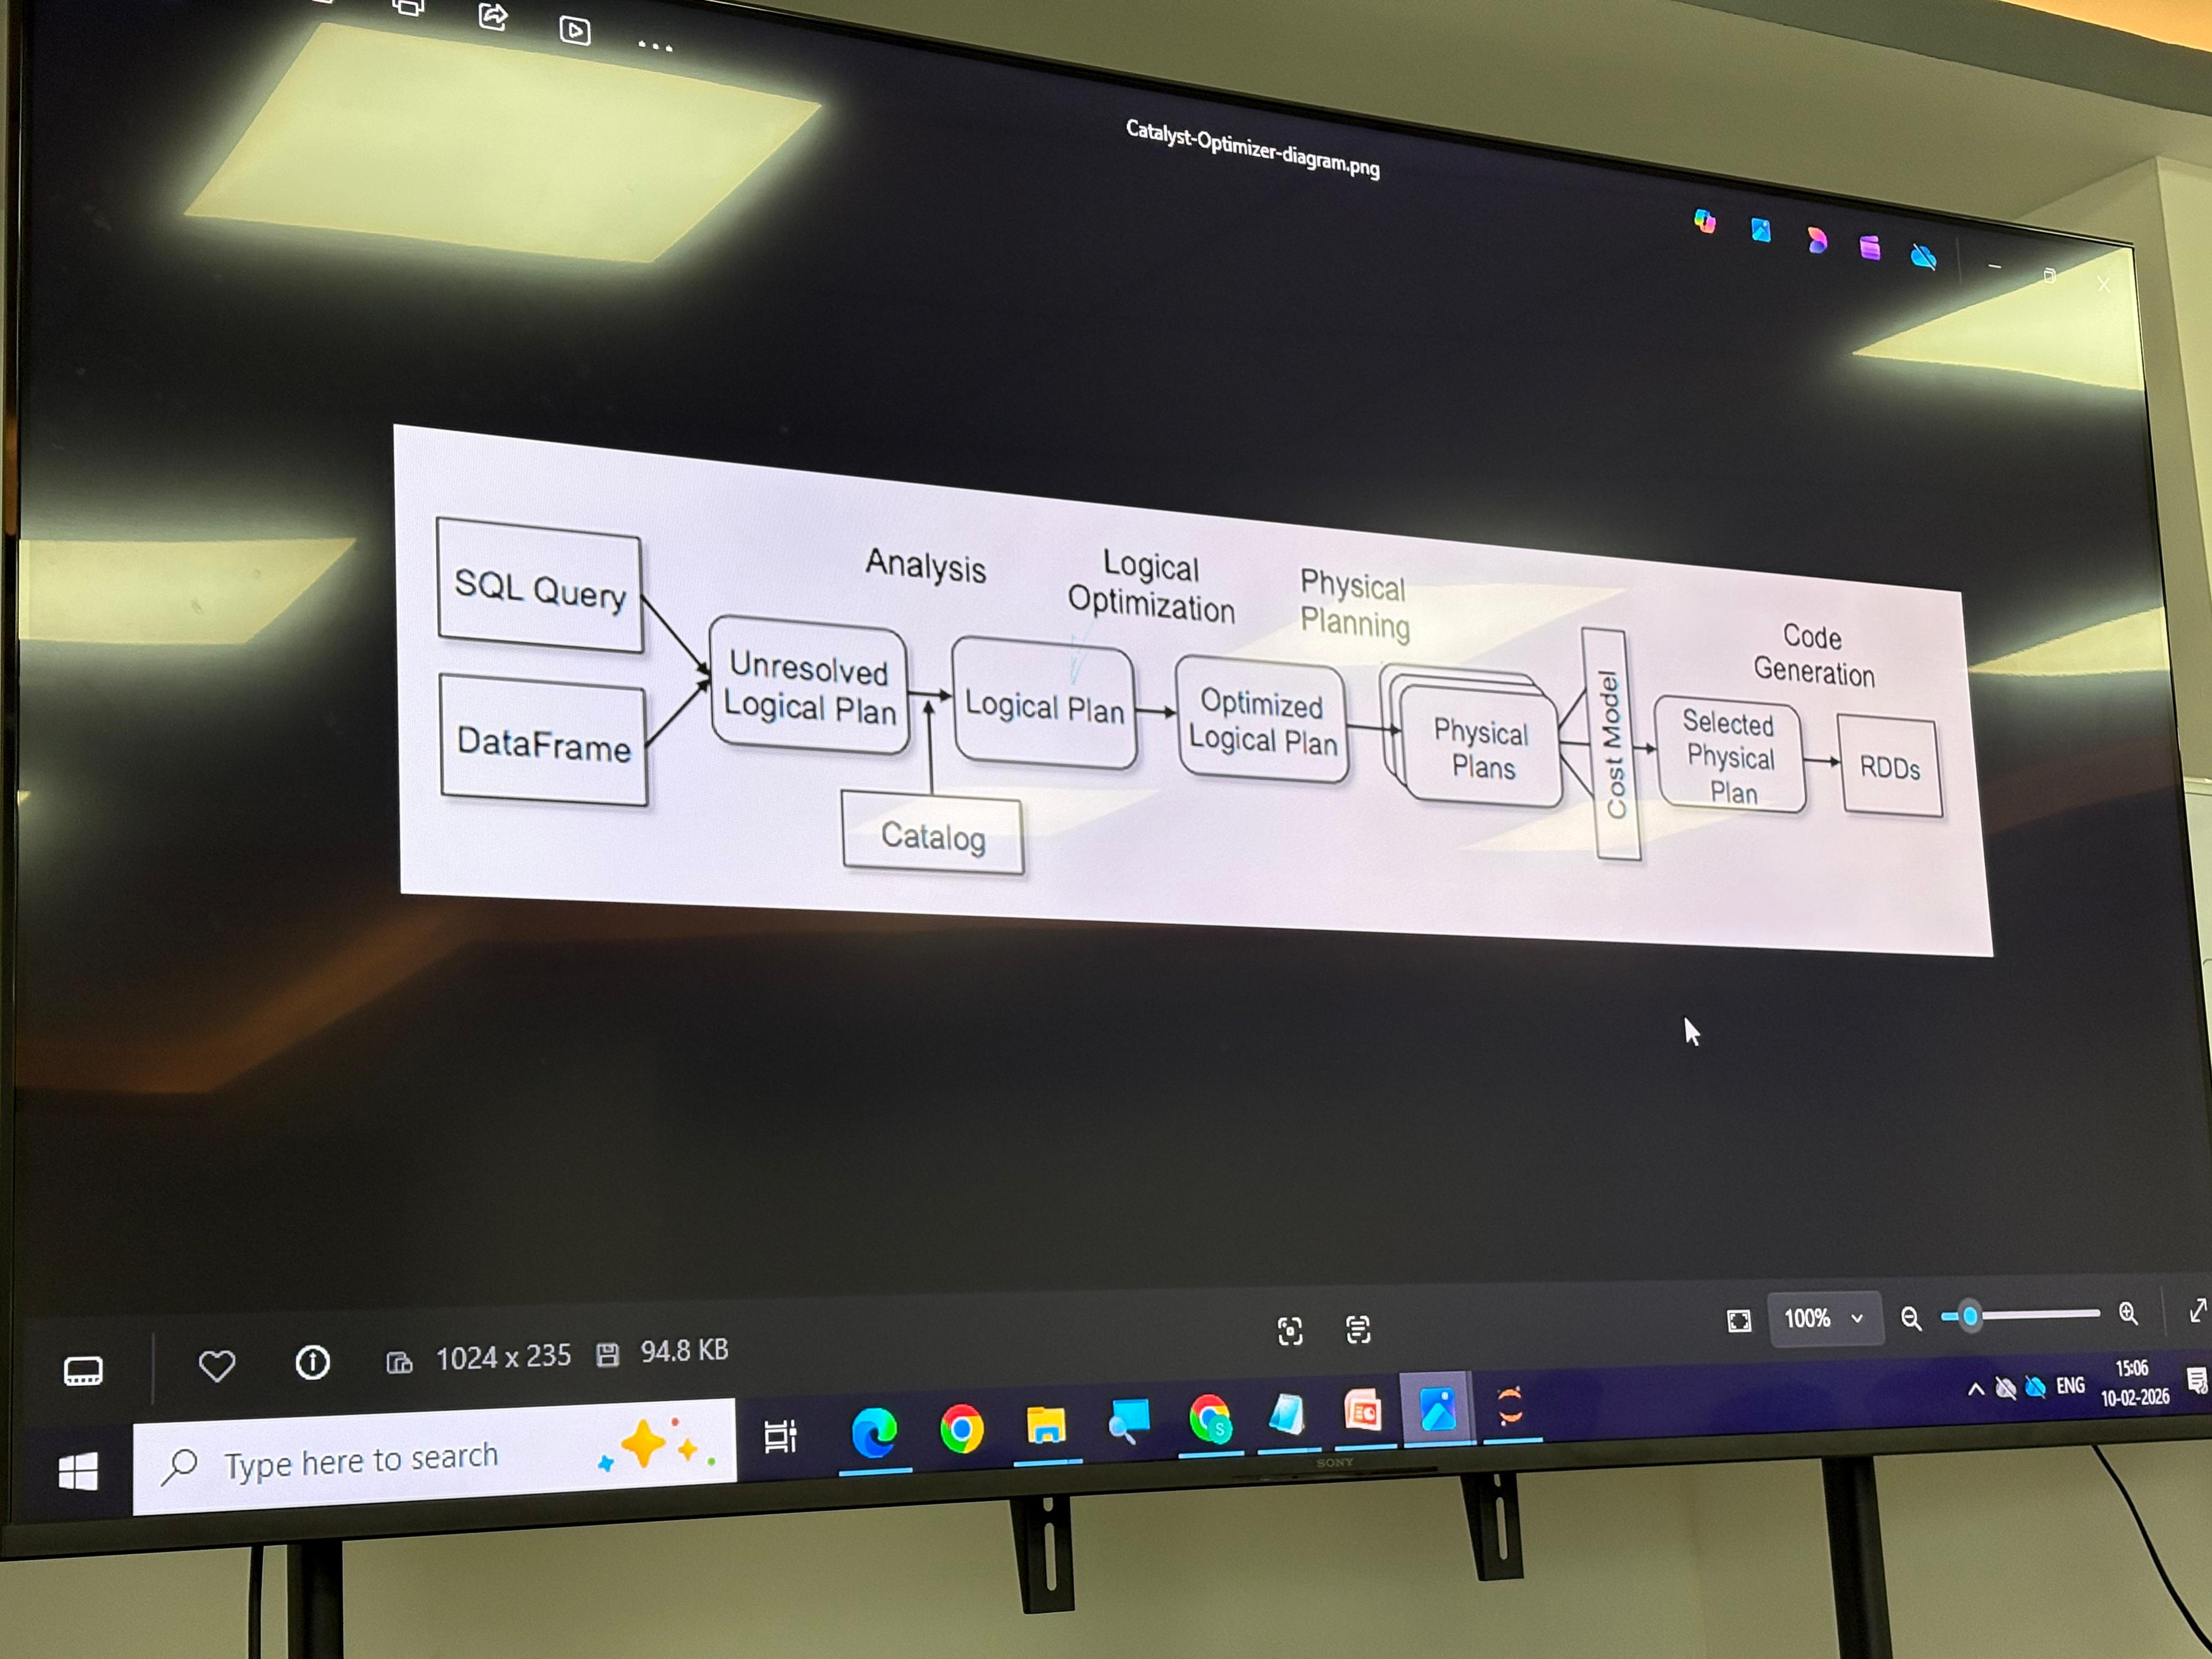

# So Catalyst will do internally ?


*   Parse it into a logical plan.
*   Optimize by pushing the filter (age > 30) closer to the data source.
*   Decide whether to scan data sequentially or use indexes.
*   Generate efficient bytecode for execution.



In [3]:
from pyspark.sql import functions as F, Window

# Example DataFrame
data = [("Alice","Sales",5000),
        ("Bob","Sales",6000),
        ("Charlie","HR",4000),
        ("David","HR",4500)]

In [8]:
df = spark.createDataFrame(data,["name","dept","salary"])

In [9]:
# Window dunction : rank employees by salary within department
windowspec = Window.partitionBy("dept").orderBy(F.desc("salary"))
df.withColumn("rank",F.rank().over(windowspec)).show()


+-------+-----+------+----+
|   name| dept|salary|rank|
+-------+-----+------+----+
|  David|   HR|  4500|   1|
|Charlie|   HR|  4000|   2|
|    Bob|Sales|  6000|   1|
|  Alice|Sales|  5000|   2|
+-------+-----+------+----+



In [10]:
# Group by department and calculate average salary
df.groupBy("dept").agg(F.avg("salary").alias("avg_salary")).show()

+-----+----------+
| dept|avg_salary|
+-----+----------+
|Sales|    5500.0|
|   HR|    4250.0|
+-----+----------+



# UDF
UDFs let you extend Spark SQL's built-in functions by writing your own custom logic in Python, scala, or Java.

In [11]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

In [12]:
# Regular UDF
def categorize_salary(salary):
  return "High" if salary > 5000 else "Low"

salary_udf = udf(categorize_salary,StringType())
df.withColumn("category",salary_udf(df["salary"])).show()

+-------+-----+------+--------+
|   name| dept|salary|category|
+-------+-----+------+--------+
|  Alice|Sales|  5000|     Low|
|    Bob|Sales|  6000|    High|
|Charlie|   HR|  4000|     Low|
|  David|   HR|  4500|     Low|
+-------+-----+------+--------+



# Nested Structures
Spark DataFrames can hold complex data types like structs, arrays, and maps. These are called nested structures because they contain multiple fields inside one column.

In [13]:
from pyspark.sql import Row

In [15]:
# Create DataFrame with nested struct
data = [Row(id = 1, info = Row(name = "Alice", age = 30)),
        Row(id = 2, info = Row(name = "Bob",age = 25))]

nested_df = spark.createDataFrame(data)

In [16]:
# Access nested fields
nested_df.select("id","info.name","info.age").show()

+---+-----+---+
| id| name|age|
+---+-----+---+
|  1|Alice| 30|
|  2|  Bob| 25|
+---+-----+---+



In [17]:
# number of blocks != number of executers

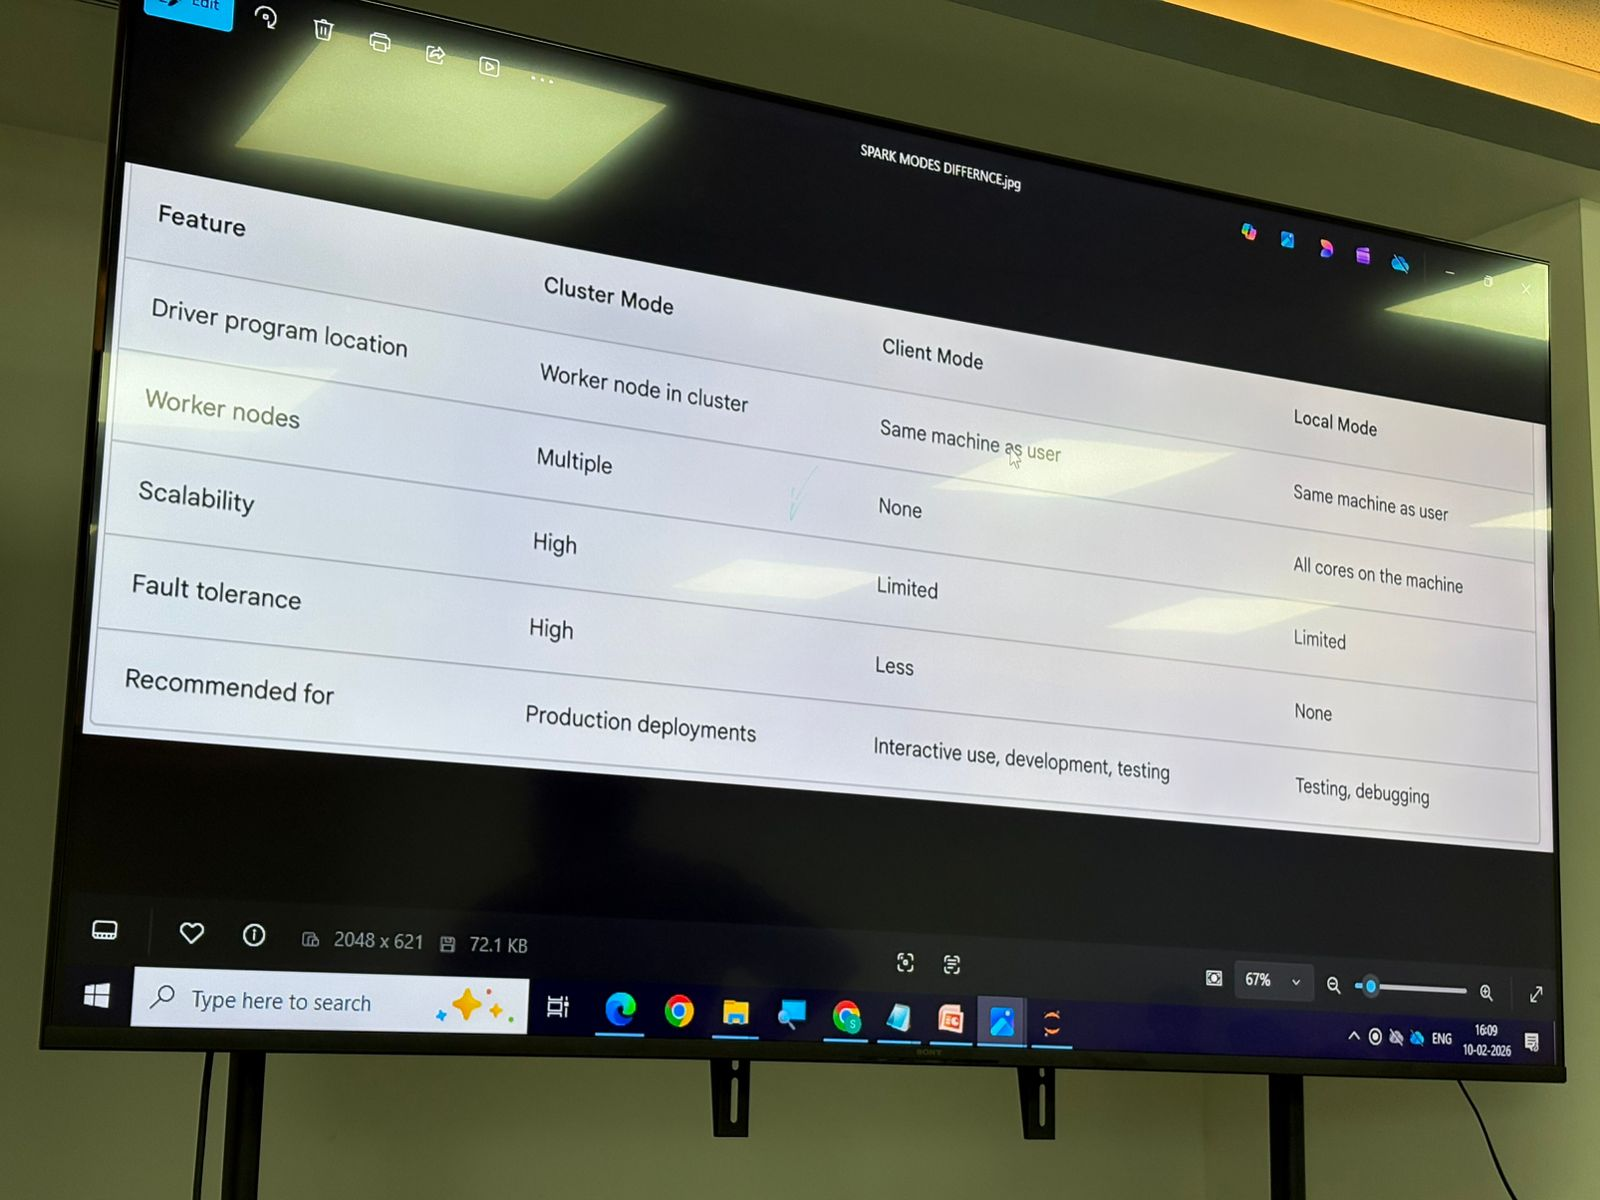

# Run on YARN in cluster mode
spark-submit \ \
--master yarn \ \
--deploy-mode cluster \ \
--num-executors 4 \ \
--executor-memory 2G \ \
--executor-cores 2 \ \
my_app.py

**Spark Engine will take this request**

# Common Causes of Slow Spark Jobs
**Data Skew** : Uneven distribution of data across partitions leads to straggler tasks.\
**Shuffles & Joins** : Wide transformations (like groupByKey, or Joins) trigger expensive shuffles.\
**Improper Partitoning** : Too few partitions -> underutilized cluster; too many -> overhead.\
**Serialization/Deserialization** : Inefficient object serialization slows down task execution.\
**Resource Bottlenecks** : Executors running out of memory, excessive garbage collection, or CPU contention.\
**Bad Coding Patterns** : Using collect() or large datasets, nested UDFs, or non-vectorized operations.